# 04 — Tablas finales, mapas 2D y GIF de abundancias

Este notebook genera tablas compactas y un GIF de la evolución de las abundancias. El GIF no es imprescindible para la memoria, pero puede servir para presentación.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

try:
    import scienceplots
    plt.style.use(["science", "grid"])
except Exception as exc:
    print("scienceplots no disponible, usando estilo por defecto:", exc)

BASE = Path.cwd()
FIG_DIR = BASE / "figures"
DATA_DIR = BASE / "data"
TAB_DIR = BASE / "tables"
GIF_DIR = BASE / "gifs"
for d in [FIG_DIR, DATA_DIR, TAB_DIR, GIF_DIR]:
    d.mkdir(exist_ok=True)

model10 = pd.read_csv(DATA_DIR / "bbn_evolution_t0_10s.csv")
model50 = pd.read_csv(DATA_DIR / "bbn_evolution_t0_50s.csv")
all_models = pd.read_csv(DATA_DIR / "bbn_evolution_all_models.csv")
snapshots = pd.read_csv(DATA_DIR / "bbn_snapshots_all_models.csv")
finals = pd.read_csv(DATA_DIR / "bbn_final_compact.csv")
obs = pd.read_csv(DATA_DIR / "observational_abundances.csv")
comparison = pd.read_csv(DATA_DIR / "comparison_models_vs_observed.csv")

In [3]:
# Tablas para Typst/LaTeX/CSV.
cols_snapshot = ["model", "t0_s", "t_s", "T9", "rho_g_cm3", "eta10", "D/H", "He3/H", "X_He4", "Li7/H", "Be7/H", "Li7_plus_Be7_over_H", "baryon_sum"]
snap_compact = snapshots[cols_snapshot].copy()
snap_compact.to_csv(TAB_DIR / "table_snapshots_models.csv", index=False)
snap_compact.to_latex(TAB_DIR / "table_snapshots_models.tex", index=False, float_format="%.4e")
snap_compact

,model,t0_s,t_s,T9,rho_g_cm3,eta10,D/H,He3/H,X_He4,Li7/H,Be7/H,Li7_plus_Be7_over_H,baryon_sum
0,t0_10s,10.0,50.0,1.7,0.000200,12.088327,2.967373e-19,4.752832e-06,2.499796e-01,2.486241e-21,1.530876e-06,1.530876e-06,1.0
1,t0_10s,10.0,200.0,1.0,0.000020,5.938995,2.943857e-19,4.554095e-06,2.499795e-01,6.553614e-21,1.614217e-06,1.614217e-06,1.0
2,t0_10s,10.0,1000.0,0.4,0.000002,9.279679,3.546831e-19,4.543060e-06,2.499795e-01,7.141584e-20,1.619403e-06,1.619403e-06,1.0
3,t0_50s,50.0,50.0,1.7,0.000200,12.088327,1.142857e-27,2.402034e-55,1.614236e-84,0.000000e+00,0.000000e+00,0.000000e+00,1.0
4,t0_50s,50.0,200.0,1.0,0.000020,5.938995,2.692124e-08,5.225594e-06,2.498882e-01,4.254565e-16,8.403180e-08,8.403180e-08,1.0
5,t0_50s,50.0,1000.0,0.4,0.000002,9.279679,5.673982e-09,5.209301e-06,2.498882e-01,4.719510e-17,9.008675e-08,9.008675e-08,1.0


In [4]:
cols_final = ["model", "t0_s", "t_s", "T9", "rho_g_cm3", "eta10", "D/H", "He3/H", "X_He4", "Li7/H", "Be7/H", "Li7_plus_Be7_over_H", "baryon_sum"]
final_compact = finals[cols_final].copy()
final_compact.to_csv(TAB_DIR / "table_final_models.csv", index=False)
final_compact.to_latex(TAB_DIR / "table_final_models.tex", index=False, float_format="%.4e")
final_compact

,model,t0_s,t_s,T9,rho_g_cm3,eta10,D/H,He3/H,X_He4,Li7/H,Be7/H,Li7_plus_Be7_over_H,baryon_sum
0,t0_50s,50.0,100000.0,0.029068,2.752180e-09,33.275187,4.979074e-09,0.000005,0.249888,1.017326e-16,9.013511e-08,9.013511e-08,1.0
1,t0_10s,10.0,100000.0,0.029068,2.752180e-09,33.275187,4.013645e-19,0.000005,0.249979,2.694339e-18,1.619445e-06,1.619445e-06,1.0


In [5]:
# Tabla comparativa observacional: modelos vs observación.
comparison.to_csv(TAB_DIR / "table_comparison_models_vs_observed.csv", index=False)
comparison.to_latex(TAB_DIR / "table_comparison_models_vs_observed.tex", index=False, float_format="%.4e")
comparison

,observable,kind,value,sigma,source
0,D/H,t0_50s,4.979074e-09,NaN,pynucastro model
1,D/H,t0_10s,4.013645e-19,NaN,pynucastro model
2,D/H,observed,2.527000e-05,3.000000e-07,Cooke2018
3,Yp_He4,t0_50s,2.498882e-01,NaN,pynucastro model
4,Yp_He4,t0_10s,2.499795e-01,NaN,pynucastro model
5,Yp_He4,observed,2.462000e-01,2.200000e-03,Aver2021
6,He3/H,t0_50s,5.209399e-06,NaN,pynucastro model
7,He3/H,t0_10s,4.542966e-06,NaN,pynucastro model
8,He3/H,observed,1.100000e-05,2.000000e-06,Steigman2010
9,Li7/H,t0_50s,9.013511e-08,NaN,pynucastro model


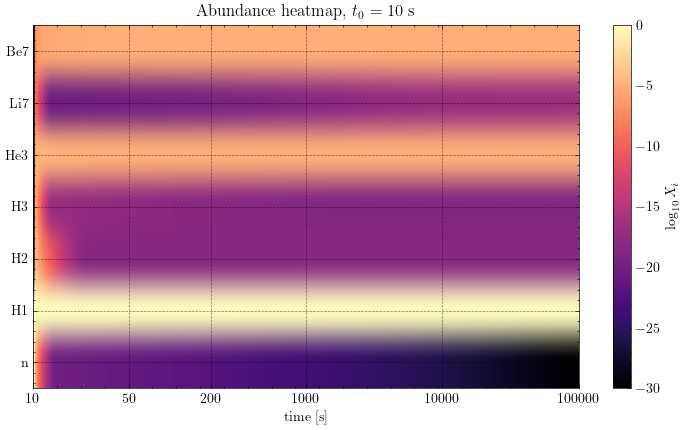

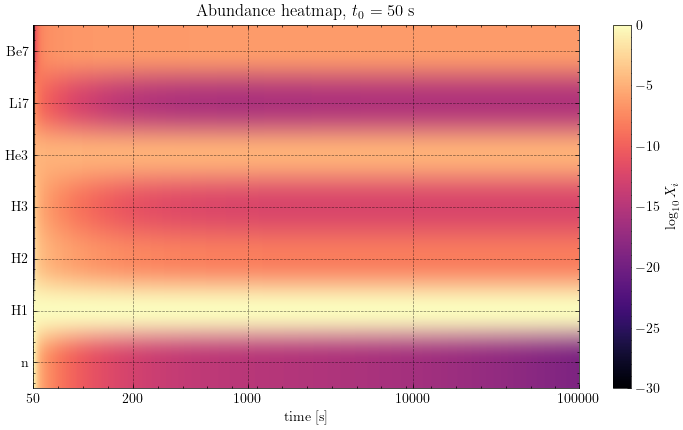

In [6]:
# Heatmap estático de log10(X_i) frente a tiempo y especie.

def abundance_cols(df):
    return [c for c in df.columns if c.startswith("X_") and c != "X_He4"]

def plot_heatmap(df, outname, title):
    cols = abundance_cols(df)
    # Re-muestreo en una malla logarítmica común para que el mapa sea legible.
    t_grid = np.geomspace(df["t_s"].min(), df["t_s"].max(), 300)
    data = []
    for col in cols:
        y = np.interp(t_grid, df["t_s"], df[col])
        data.append(np.log10(np.clip(y, 1e-30, None)))
    data = np.array(data)
    fig, ax = plt.subplots(figsize=(7.4, 4.5))
    im = ax.imshow(data, aspect="auto", origin="lower", cmap="magma",
                   extent=[np.log10(t_grid.min()), np.log10(t_grid.max()), -0.5, len(cols)-0.5],
                   vmin=-30, vmax=0)
    ax.set_yticks(np.arange(len(cols)))
    ax.set_yticklabels([c[2:] for c in cols])
    xticks = np.array([10, 50, 200, 1000, 1e4, 1e5])
    xticks = xticks[(xticks >= t_grid.min()) & (xticks <= t_grid.max())]
    ax.set_xticks(np.log10(xticks))
    ax.set_xticklabels([f"{x:g}" for x in xticks])
    ax.set_xlabel("time [s]")
    ax.set_title(title)
    cb = fig.colorbar(im, ax=ax)
    cb.set_label(r"$\log_{10} X_i$")
    fig.tight_layout()
    fig.savefig(FIG_DIR / outname)
    plt.show()

plot_heatmap(model10, "fig_heatmap_abundances_t0_10s.pdf", r"Abundance heatmap, $t_0=10$ s")
plot_heatmap(model50, "fig_heatmap_abundances_t0_50s.pdf", r"Abundance heatmap, $t_0=50$ s")

In [7]:
# GIF: evolución de las abundancias como barras logarítmicas.
# Puede tardar unos segundos. Si Pillow no está instalado: pip install pillow

def make_abundance_gif(df, outname, title, nframes=80):
    cols = abundance_cols(df)
    names = [c[2:] for c in cols]
    frame_times = np.geomspace(df["t_s"].min(), df["t_s"].max(), nframes)
    fig, ax = plt.subplots(figsize=(7.0, 4.5))
    x = np.arange(len(cols))
    initial = np.ones(len(cols))*1e-30
    bars = ax.bar(x, initial)
    ax.set_yscale("log")
    ax.set_ylim(1e-30, 1.2)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha="right")
    ax.set_ylabel(r"mass fraction $X_i$")
    title_obj = ax.set_title(title)

    def update(frame):
        t = frame_times[frame]
        vals = []
        for col in cols:
            vals.append(max(np.interp(t, df["t_s"], df[col]), 1e-30))
        for b, v in zip(bars, vals):
            b.set_height(v)
        title_obj.set_text(f"{title} — t = {t:.2e} s")
        return list(bars) + [title_obj]

    anim = FuncAnimation(fig, update, frames=nframes, interval=100, blit=False)
    anim.save(GIF_DIR / outname, writer=PillowWriter(fps=10))
    plt.close(fig)

make_abundance_gif(model10, "gif_abundances_t0_10s.gif", "BBN abundances t0=10 s")
make_abundance_gif(model50, "gif_abundances_t0_50s.gif", "BBN abundances t0=50 s")
print("GIFs guardados en", GIF_DIR)

GIFs guardados en /home/daniel/GitHub/BNN_simulation/main/gifs
